# Zadanie: Klasyfikacja zboir Heart Disease

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, RocCurveDisplay)



sns.set_theme(style="whitegrid")

## 1. Wczytanie i analiza danych
Zbiór Heart Disease Cleveland ma 13 cech pacjentów i jedną zmienną docelową (0 - brak choroby, wartości 1-4 - różne stadia choroby). Traktuje to jako problem klasyfikacji binarnej (chory / zdrowy)

**Opis atrybutów (Data Dictionary):**

| Nazwa kolumny | Opis | Typ danych |
| :--- | :--- | :--- |
| **age** | Wiek pacjenta w latach | Ciągłe |
| **sex** | Płeć (1 = mężczyzna; 0 = kobieta) | Kategoryczne (Binarne) |
| **cp** | Typ bólu w klatce piersiowej (1: typowa dławica, 2: nietypowa dławica, 3: ból niedławicowy, 4: bezobjawowy) | Kategoryczne |
| **trestbps** | Spoczynkowe ciśnienie krwi (w mm Hg przy przyjęciu do szpitala) | Ciągłe |
| **chol** | Poziom cholesterolu w surowicy w mg/dl | Ciągłe |
| **fbs** | Poziom cukru we krwi na czczo > 120 mg/dl (1 = prawda; 0 = fałsz) | Kategoryczne (Binarne) |
| **restecg** | Spoczynkowe wyniki EKG (0: normalne, 1: nieprawidłowość załamka ST-T, 2: przerost lewej komory) | Kategoryczne |
| **thalach** | Maksymalne osiągnięte tętno pacjenta | Ciągłe |
| **exang** | Dławica piersiowa wywołana wysiłkiem (1 = tak; 0 = nie) | Kategoryczne (Binarne) |
| **oldpeak** | Obniżenie odcinka ST wywołane wysiłkiem względem stanu spoczynku | Ciągłe |
| **slope** | Nachylenie szczytowego wysiłkowego odcinka ST (1: wznoszące, 2: płaskie, 3: opadające) | Kategoryczne |
| **ca** | Liczba głównych naczyń (0-3) zabarwionych w fluoroskopii | Numeryczne / Kategoryczne |
| **thal** | Wynik testu talowego (3 = normalny; 6 = wada naprawiona; 7 = wada odwracalna) | Kategoryczne |
| **target** | Diagnoza (0 = brak choroby serca, 1,2,3,4 = obecność choroby w różnym stadium) | Docelowa (Klasa) |

In [50]:
df = pd.read_csv("Heart_disease_cleveland_new.csv")


print("Próbka danych (pierwsze 5 wierszy):")
display(df.head())


print("\nInformacje o typach danych:")
display(df.info())

print("Opis danych:")
display(df.describe().round(2))

#usuwam
df.dropna(inplace=True)
if df['target'].max() > 1:
    df['target'] = (df['target'] > 0).astype(int)


Próbka danych (pierwsze 5 wierszy):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0



Informacje o typach danych:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


None

Opis danych:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,2.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,0.60,0.66,1.83,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,0.96,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,48.00,0.00,2.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,0.00,0.00,1.00,0.00
50%,56.00,1.00,2.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,1.00,0.00
75%,61.00,1.00,3.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,1.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,3.00,3.00,1.00


## Wykresy zawierajace odchylenia oraz zalności między danymi

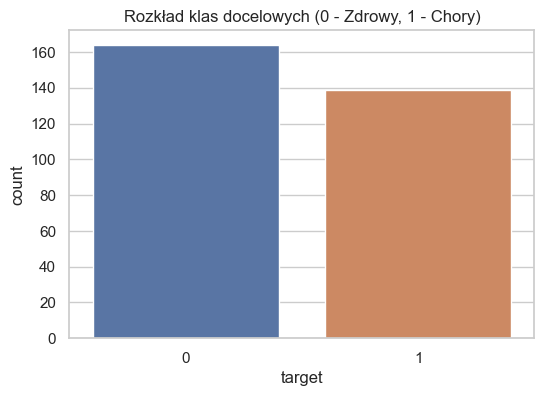

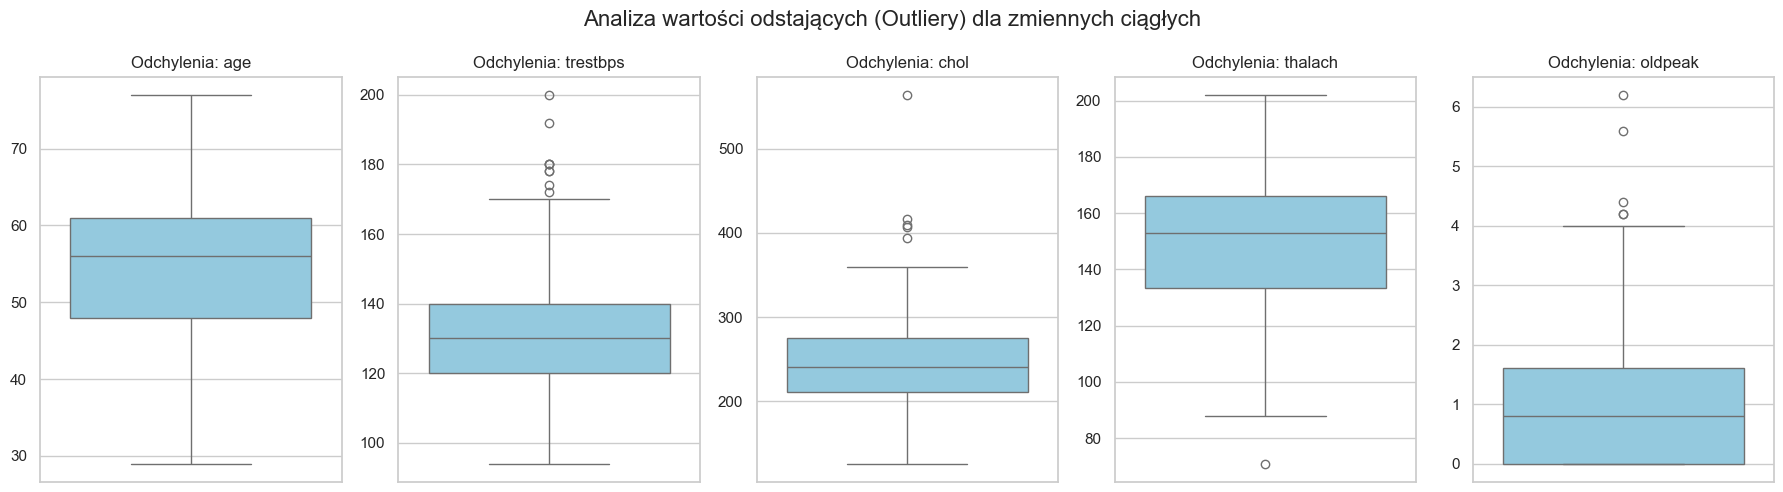

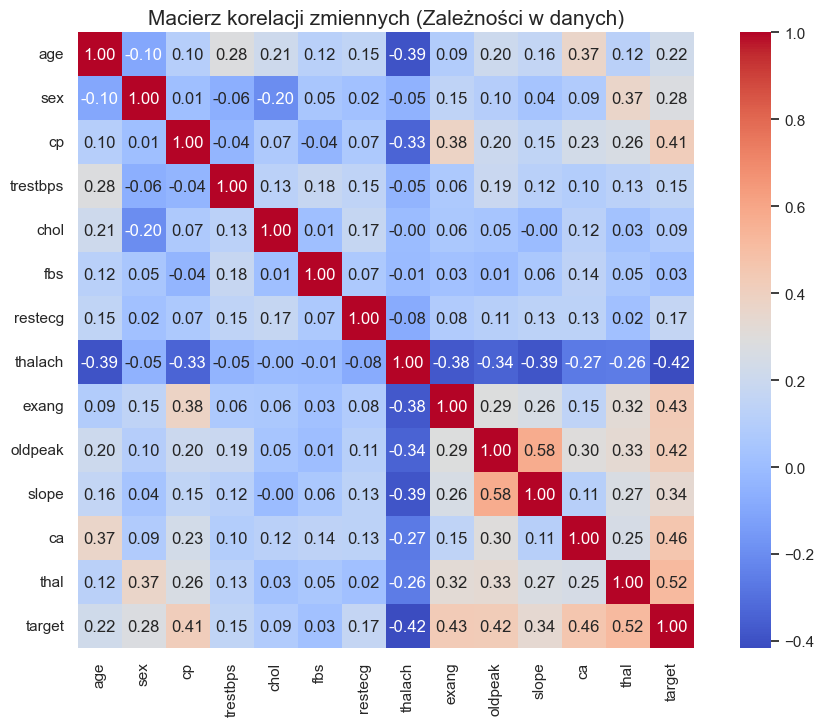

In [51]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', legend=False)
plt.title("Rozkład klas docelowych (0 - Zdrowy, 1 - Chory)")
plt.show()



#ouliers
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 5))
for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Odchylenia: {col}')
    axes[i].set_ylabel('')
plt.suptitle("Analiza wartości odstających (Outliery) dla zmiennych ciągłych", fontsize=16)
plt.tight_layout()
plt.show()


#heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True)
plt.title("Macierz korelacji zmiennych (Zależności w danych)", fontsize=15)
plt.show()

### Podział zbioru na testowy i do uczenia 

In [52]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nRozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")


Rozmiar zbioru treningowego: (242, 13)
Rozmiar zbioru testowego: (61, 13)


## 2. i 3. Trening modelu regresji logistycznej i ocena działania

Trenuje bazowy model regresji logistycznej na surowych danych i oceniam jego skuteczność. 

**Interpretacja miar (Zadanie 3):**
Miary Czułość (Recall) oraz Precyzja (Precision)

* Czułość (Recall): Jest to najważniejsza metryka w diagnozie medycznej. Mówi o tym, jaki procent faktycznie chorych pacjentów nasz model poprawnie zdiagnozował. Zależy nam na jej maksymalizacji, ponieważ odesłanie chorego pacjenta do domu (Fałszywie Negatywny - False Negative) może zagrażać jego życiu.

* Precyzja (Precision): Wskazuje, jaki procent pacjentów zdiagnozowanych przez model jako chorych, faktycznie choruje. Niższa precyzja oznacza więcej fałszywych alarmów (zdrowy pacjent wysłany na dodatkowe badania). W medycynie jesteśmy w stanie zaakceptować niższą precyzję.

Raport Klasyfikacji:

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



/Users/tomekorman/Documents/PWR/Semestr 2/Uczenie maszynowe/Laboratoria/Lista_3/lista-3-tomek2005/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


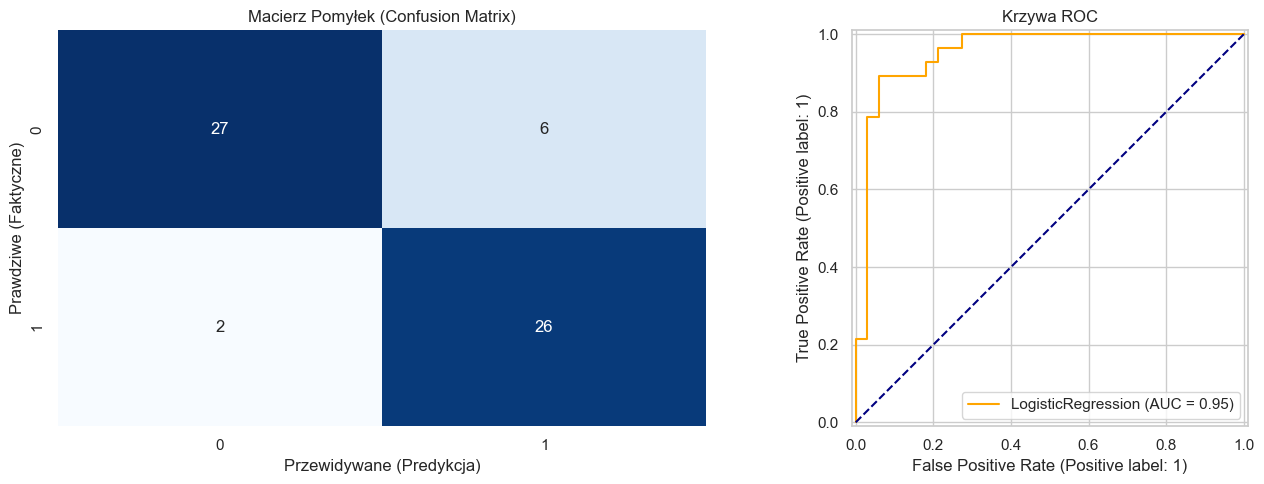

In [53]:
#zad2
base_model = LogisticRegression(max_iter=1000, random_state=42)
base_model.fit(X_train, y_train)


#zad3
y_pred = base_model.predict(X_test)

print("Raport Klasyfikacji:\n")
print(classification_report(y_test, y_pred))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Macierz Pomyłek (Confusion Matrix)')
axes[0].set_xlabel('Przewidywane (Predykcja)')
axes[0].set_ylabel('Prawdziwe (Faktyczne)')


RocCurveDisplay.from_estimator(base_model, X_test, y_test, ax=axes[1], color="orange")
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('Krzywa ROC')

plt.tight_layout()
plt.show()

## 4. Wpływ standaryzacji i normalizacji danych

Regresja logistyczna w `scikit-learn` używa regularyzacji. jak cechy mają drastycznie różną skalę , algorytm może niesłusznie przypisać większą wagę zmiennym o wyższych wartościach. 
Sprawdzimy, jak na wyniki wpływa standaryzacja i normalizacja.

In [54]:
#zad4
#Standaryzacja
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

# Normalizacja
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

datasets = {
    "Surowe dane (Brak skalowania)": (X_train, X_test),
    "Standaryzacja": (X_train_std, X_test_std),
    "Normalizacja": (X_train_mm, X_test_mm)
}

results_scale = []
for name, (X_tr, X_ts) in datasets.items():
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_train)
    acc = accuracy_score(y_test, model.predict(X_ts))
    results_scale.append({'Metoda skalowania': name, 'Accuracy na teście': acc})

df_scale = pd.DataFrame(results_scale)
display(df_scale)

,Metoda skalowania,Accuracy na teście
0,Surowe dane (Brak skalowania),0.868852
1,Standaryzacja,0.868852
2,Normalizacja,0.852459


## 5. Badanie hiperparametrów

badam wpływ siły regularyzacji (`C`) oraz proporcji kar l1/l2 (`l1_ratio`).

badam tez liczbę iteracji, jakiej algorytm potrzebuje do zbieżności.

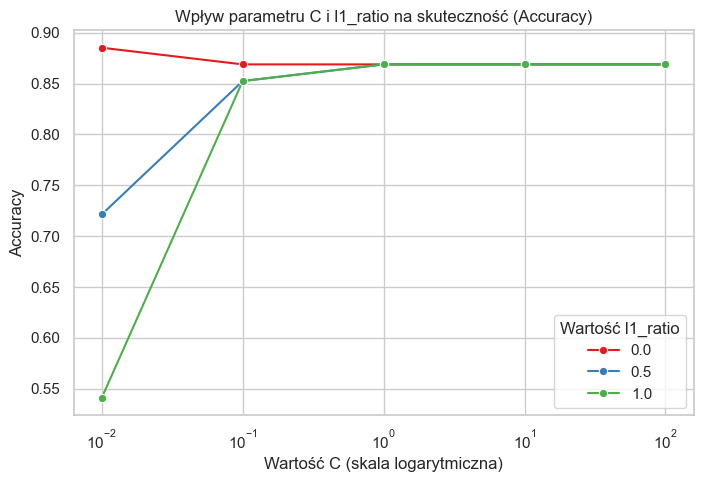

Tabela wyników - wpływ hiperparametrów i liczba iteracji:


,C (Siła Reg.),l1_ratio,Wymagane Iteracje,Accuracy
0,0.01,0.0,14,0.885246
1,0.01,0.5,15,0.721311
2,0.01,1.0,3,0.540984
3,0.10,0.0,16,0.868852
4,0.10,0.5,18,0.852459
5,0.10,1.0,16,0.852459
6,1.00,0.0,21,0.868852
7,1.00,0.5,21,0.868852
8,1.00,1.0,21,0.868852
9,10.00,0.0,23,0.868852


In [55]:
C_values = [0.01, 0.1, 1, 10, 100]
l1_ratios = [0.0, 0.5, 1.0]

results_hp = []

for c in C_values:
    for l1 in l1_ratios:
        model_hp = LogisticRegression(
            solver='saga', C=c, l1_ratio=l1, 
            max_iter=1000, random_state=42
        )
        model_hp.fit(X_train_std, y_train)
        
        actual_iters = model_hp.n_iter_[0]
        
        acc = accuracy_score(y_test, model_hp.predict(X_test_std))
        
        results_hp.append({
            'C (Siła Reg.)': c, 
            'l1_ratio': l1, 
            'Wymagane Iteracje': actual_iters,
            'Accuracy': acc
        })

df_hp = pd.DataFrame(results_hp)

plt.figure(figsize=(8, 5))
df_hp['l1_ratio_str'] = df_hp['l1_ratio'].astype(str)

sns.lineplot(data=df_hp, x='C (Siła Reg.)', y='Accuracy', hue='l1_ratio_str', marker='o', palette='Set1')
plt.xscale('log')
plt.title("Wpływ parametru C i l1_ratio na skuteczność (Accuracy)")
plt.xlabel("Wartość C (skala logarytmiczna)")
plt.legend(title='Wartość l1_ratio')
plt.show()

print("Tabela wyników - wpływ hiperparametrów i liczba iteracji:")
display(df_hp.drop('l1_ratio_str', axis=1))

## 6. Walidacja krzyżowa (Cross-validation) i Stratyfikacja

Dzieląc zbiór tylko raz (na train/test), wynik może zależeć od szczęśliwego losowania. Walidacja krzyżowa (CV) dzieli zbiór na K części i trenuje model K razy, uśredniając wyniki.

Wyniki walidacji krzyżowej:


Średnie Accuracy                 Odchylenie Std (Zmienność)  \
Metoda         KFold (Zwykły) StratifiedKFold             KFold (Zwykły)   
K (podziały)                                                               
2                      0.8058          0.8388                     0.0289   
5                      0.8013          0.8304                     0.0713   
10                     0.8220          0.8183                     0.0752   

                              
Metoda       StratifiedKFold  
K (podziały)                  
2                     0.0041  
5                     0.0248  
10                    0.0482

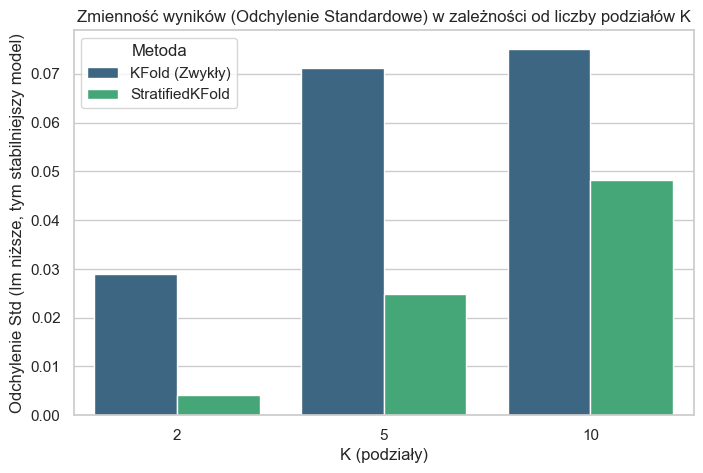

In [56]:
splits = [2, 5, 10]
cv_results = []

model_cv = LogisticRegression(max_iter=1000, random_state=42)

for k in splits:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores_kf = cross_val_score(model_cv, X_train_std, y_train, cv=kf, scoring='accuracy')
    
    cv_results.append({
        'K (podziały)': k,
        'Metoda': 'KFold (Zwykły)',
        'Średnie Accuracy': np.mean(scores_kf),
        'Odchylenie Std (Zmienność)': np.std(scores_kf)
    })
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores_skf = cross_val_score(model_cv, X_train_std, y_train, cv=skf, scoring='accuracy')
    
    cv_results.append({
        'K (podziały)': k,
        'Metoda': 'StratifiedKFold',
        'Średnie Accuracy': np.mean(scores_skf),
        'Odchylenie Std (Zmienność)': np.std(scores_skf)
    })

df_cv = pd.DataFrame(cv_results)


df_cv_pivot = df_cv.pivot(index='K (podziały)', columns='Metoda', values=['Średnie Accuracy', 'Odchylenie Std (Zmienność)'])
print("Wyniki walidacji krzyżowej:")
display(df_cv_pivot.round(4))


plt.figure(figsize=(8, 5))
sns.barplot(data=df_cv, x='K (podziały)', y='Odchylenie Std (Zmienność)', hue='Metoda', palette='viridis')
plt.title("Zmienność wyników (Odchylenie Standardowe) w zależności od liczby podziałów K")
plt.ylabel("Odchylenie Std (Im niższe, tym stabilniejszy model)")
plt.show()
